<a href="https://colab.research.google.com/github/Amarnath2908/Celebal-Excellence-Internship/blob/main/Week4_BAmarnath.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2474s 15us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

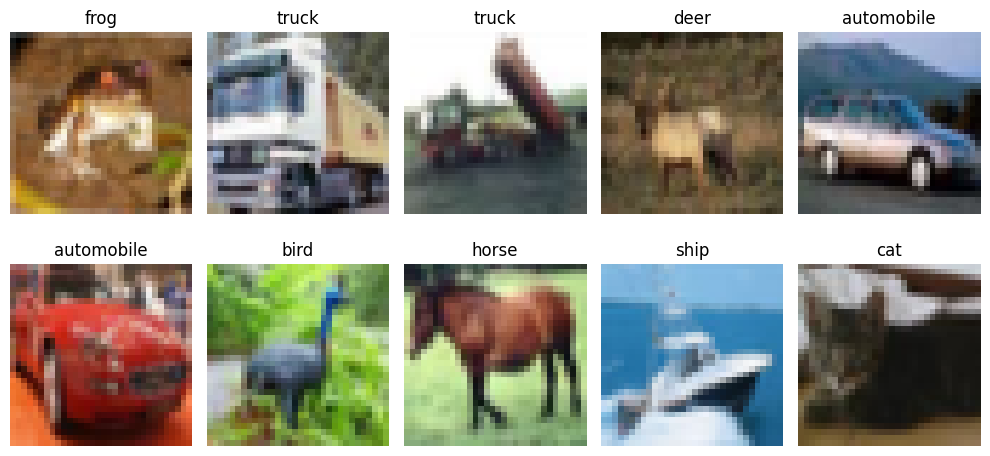

In [55]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [56]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [57]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.2742 - loss: 1.9963 - val_accuracy: 0.3436 - val_loss: 1.8230
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3261 - loss: 1.8598 - val_accuracy: 0.3636 - val_loss: 1.7826
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3468 - loss: 1.8026 - val_accuracy: 0.3732 - val_loss: 1.7529
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3576 - loss: 1.7692 - val_accuracy: 0.3740 - val_loss: 1.7361
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3713 - loss: 1.7366 - val_accuracy: 0.4126 - val_loss: 1.6732
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3778 - loss: 1.7139 - val_accuracy: 0.3894 - val_loss: 1.7158
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3854 - loss: 1.7014 - val_accuracy: 0.3922 - val_loss: 1.7191
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3891 - loss: 1.6857 - val_accuracy: 0.

In [58]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4446 - loss: 1.5843
ANN Test Accuracy: 0.444599986076355


# TASK

In [59]:
from tensorflow.keras.callbacks import EarlyStopping


In [60]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

MODEL BUILDING

In [61]:
ann_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

COMPILATION

In [62]:


ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

TRAINING

In [63]:

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=50,
    validation_split=0.1,
    batch_size=64,
    verbose = 1

)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.2575 - loss: 2.0097 - val_accuracy: 0.3352 - val_loss: 1.8437
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3171 - loss: 1.8633 - val_accuracy: 0.3428 - val_loss: 1.8308
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3420 - loss: 1.8083 - val_accuracy: 0.3772 - val_loss: 1.7198
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3514 - loss: 1.7807 - val_accuracy: 0.3906 - val_loss: 1.7206
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3556 - loss: 1.7600 - val_accuracy: 0.3948 - val_loss: 1.7124
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3698 - loss: 1.7316 - val_accuracy: 0.3908 - val_loss: 1.7072
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3780 - loss: 1.7123 - val_accuracy: 0.4108 - val_loss: 1.6595
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3802 - loss: 1.7058 - val_accuracy: 0.

In [64]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4762 - loss: 1.4706
ANN Test Accuracy: 0.47620001435279846


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [65]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4693 - loss: 1.4797 - val_accuracy: 0.5178 - val_loss: 1.3899
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6108 - loss: 1.1169 - val_accuracy: 0.6458 - val_loss: 1.0188
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6717 - loss: 0.9435 - val_accuracy: 0.6464 - val_loss: 1.0195
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7122 - loss: 0.8282 - val_accuracy: 0.6652 - val_loss: 0.9643
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7406 - loss: 0.7424 - val_accuracy: 0.6572 - val_loss: 1.0068
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7698 - loss: 0.6598 - val_accuracy: 0.7248 - val_loss: 0.8129
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7940 - loss: 0.5852 - val_accuracy: 0.7008 - val_loss: 0.9468
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8106 - loss: 0.5292 - val_accuracy: 

In [66]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6893 - loss: 1.1346
CNN Test Accuracy: 0.689300000667572


# TASK

64,128,256

In [67]:
early_stop_cnn = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [68]:
cnn_model = models.Sequential([

    layers.Input(shape=(32,32,3)),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),

    layers.GlobalAveragePooling2D(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [69]:


cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_cnn]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - accuracy: 0.4696 - loss: 1.4314 - val_accuracy: 0.4684 - val_loss: 1.5672
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6205 - loss: 1.0657 - val_accuracy: 0.5986 - val_loss: 1.1494
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6737 - loss: 0.9206 - val_accuracy: 0.6788 - val_loss: 0.9041
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7078 - loss: 0.8260 - val_accuracy: 0.7042 - val_loss: 0.8538
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7382 - loss: 0.7485 - val_accuracy: 0.7270 - val_loss: 0.8065
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7592 - loss: 0.6915 - val_accuracy: 0.7766 - val_loss: 0.6520
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7783 - loss: 0.6415 - val_accuracy: 0.6882 - val_loss: 0.9487
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7910 - loss: 0.6051 - val_accuracy: 

In [70]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7945 - loss: 0.5976
CNN Test Accuracy: 0.7944999933242798


## 📈 Compare Learning Curves

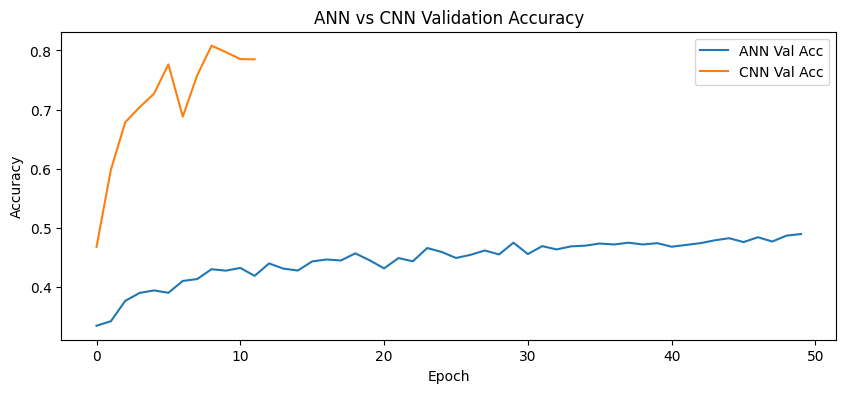

In [71]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

# TASK

In [82]:
early_stop_aug = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

In [83]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05)
])
aug_cnn_model = models.Sequential([

    layers.Input(shape=(32, 32, 3)),

    data_augmentation,

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),

    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.4),

    layers.GlobalAveragePooling2D(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

In [84]:

aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop_aug],
    verbose=1
)

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.4312 - loss: 1.5372 - val_accuracy: 0.4182 - val_loss: 1.8224
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5702 - loss: 1.1902 - val_accuracy: 0.6334 - val_loss: 1.0333
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6281 - loss: 1.0394 - val_accuracy: 0.5682 - val_loss: 1.2463
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6667 - loss: 0.9423 - val_accuracy: 0.7150 - val_loss: 0.8444
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6954 - loss: 0.8646 - val_accuracy: 0.7126 - val_loss: 0.8566
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.7157 - loss: 0.8062 - val_accuracy: 0.7336 - val_loss: 0.7650
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7320 - loss: 0.7688 - val_accuracy: 0.7012 - val_loss: 0.8798
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7474 - loss: 0.7259 - 

In [85]:
aug_loss, aug_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test,
    verbose=0
)

In [86]:
print(aug_acc)

0.8629999756813049


# 📊 Final Comparison Table

In [87]:
comparison = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "Augmented CNN"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_acc
    ]
})

print("\nModel Comparison")
print(comparison)


Model Comparison
           Model  Test Accuracy
0            ANN         0.4762
1            CNN         0.7945
2  Augmented CNN         0.8630


# ACCURACY COMPARSION GRAPH

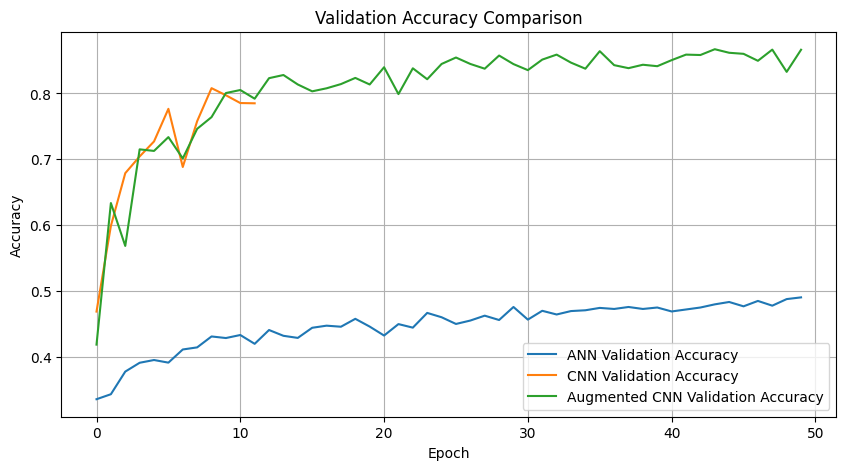

In [88]:

plt.figure(figsize=(10,5))

plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN Validation Accuracy'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN Validation Accuracy'
)

plt.plot(
    aug_history.history['val_accuracy'],
    label='Augmented CNN Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.grid(True)

plt.show()


# LOSS COMPARISON GRAPH

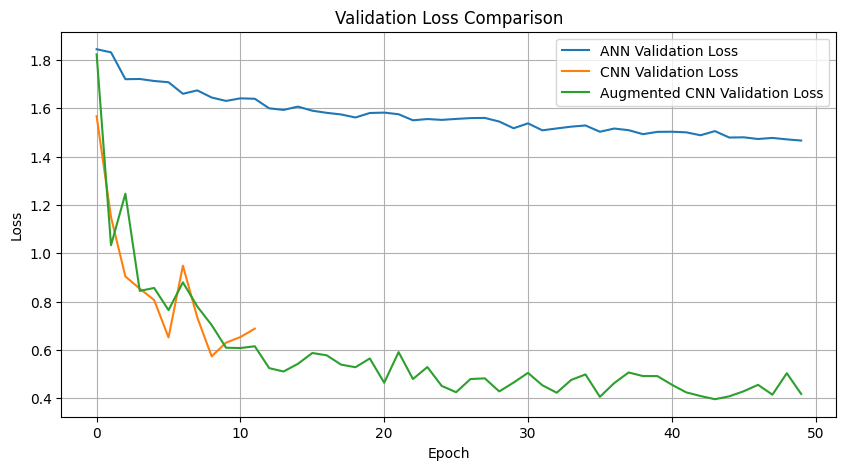

In [89]:

plt.figure(figsize=(10,5))

plt.plot(
    ann_history.history['val_loss'],
    label='ANN Validation Loss'
)

plt.plot(
    cnn_history.history['val_loss'],
    label='CNN Validation Loss'
)

plt.plot(
    aug_history.history['val_loss'],
    label='Augmented CNN Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step


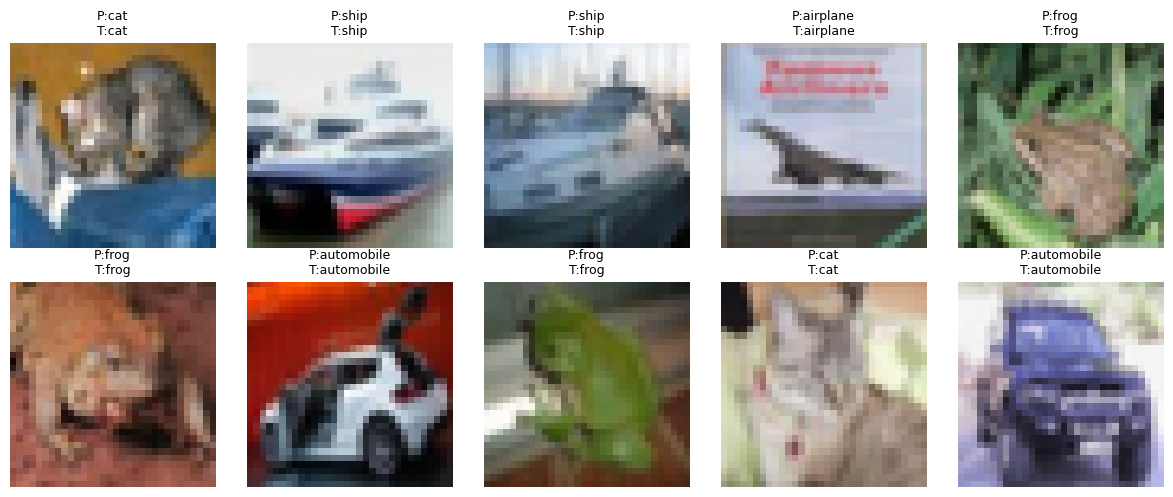

In [90]:

predictions = aug_cnn_model.predict(x_test_norm[:10])

plt.figure(figsize=(12,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[i])

    pred_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[y_test[i][0]]

    plt.title(
        f"P:{pred_label}\nT:{true_label}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**